### 1. 基础准备
#### 1.1 测试CLIP能否正常运行

In [1]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 随便找张图测试
image = preprocess(Image.open("dog.png")).unsqueeze(0).to(device)
text = clip.tokenize(["a dog", "a cat"]).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image, text)
    print(logits_per_image) # 如果能输出数字，说明环境好了

tensor([[27.4531, 22.5312]], device='cuda:0', dtype=torch.float16)


#### 1.2 下载微型ImageNet数据集

In [2]:
import os
import requests
import tarfile
from tqdm import tqdm # 如果没有安装，请运行 pip install tqdm

# 配置
DATA_DIR = "./data"
URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
FILENAME = "imagenette2-320.tgz"
TARGET_FOLDER = os.path.join(DATA_DIR, "imagenette2-320")

def download_and_extract():
    # 1. 创建目录
    if not os.path.exists(DATA_DIR):
        os.makedirs(DATA_DIR)
        print(f"Created directory: {DATA_DIR}")

    file_path = os.path.join(DATA_DIR, FILENAME)

    # 2. 检查是否已经下载
    if os.path.exists(TARGET_FOLDER):
        print(f"Dataset already exists at {TARGET_FOLDER}. Skipping download.")
        return TARGET_FOLDER

    # 3. 下载文件 (带进度条)
    print(f"Downloading Imagenette (ImageNet Subset) from {URL}...")
    response = requests.get(URL, stream=True)
    total_size = int(response.headers.get('content-length', 0))

    with open(file_path, "wb") as file, tqdm(
        desc=FILENAME,
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(chunk_size=1024):
            size = file.write(data)
            bar.update(size)

    # 4. 解压文件
    print("Extracting files...")
    with tarfile.open(file_path, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)

    # 5. 清理压缩包 (可选)
    # os.remove(file_path)
    print(f"Done! Data is ready at: {TARGET_FOLDER}")
    return TARGET_FOLDER

if __name__ == "__main__":
    data_path = download_and_extract()

    print("\n" + "="*40)
    print("数据准备完成！")
    print(f"训练集路径: {os.path.join(data_path, 'train')}")
    print(f"验证集路径: {os.path.join(data_path, 'val')}")
    print("="*40)

imagenette2-320.tgz: 100%|██████████| 326M/326M [01:34<00:00, 3.62MiB/s]   


Extracting files...
Done! Data is ready at: ./data/imagenette2-320

数据准备完成！
训练集路径: ./data/imagenette2-320/train
验证集路径: ./data/imagenette2-320/val


#### 1.3 加载数据集

In [6]:
# Imagenette 的 10 个类别 ID 到 英文名称 的映射
# 这对于构建 Prompt "A photo of a {name}" 至关重要

IMAGENETTE_CLASSES = {
    "n01440764": "tench",            # 丁鱥 (一种鱼)
    "n02102040": "English springer", # 英国史宾格犬
    "n02979186": "cassette player",  # 盒式录音机
    "n03000684": "chain saw",        # 电锯
    "n03028079": "church",           # 教堂
    "n03394916": "French horn",      # 法国号
    "n03417042": "garbage truck",    # 垃圾车
    "n03425413": "gas pump",         # 加油泵
    "n03445777": "golf ball",        # 高尔夫球
    "n03888257": "parachute"         # 降落伞
}

# 示例：如何使用 torchvision 加载并获取正确的 class name
import torchvision.datasets as datasets

# 加载数据
dataset = datasets.ImageFolder("./data/imagenette2-320/train")

# 获取类别名称列表 (按文件夹顺序排序)
class_names = [IMAGENETTE_CLASSES[id] for id in dataset.classes]

print("Class names for CLIP:", class_names)
# 输出: ['tench', 'English springer', ...]

Class names for CLIP: ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']


### 2. Baseline (Zero-shot CLIP) 复现

In [7]:
import torch
import clip
from PIL import Image
import os
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm

# =================配置部分=================
# 设备配置：有显卡用显卡，没显卡用CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 数据集路径 (建议使用 'val' 文件夹来做测试，因为 train 将来要用于训练)
DATA_PATH = "./data/imagenette2-320/val"

# 修正后的类别字典
IMAGENETTE_CLASSES = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute"
}

# =================步骤 1: 加载模型=================
print("Loading CLIP model...")
# 加载 ViT-B/32 模型 (最常用的版本)
model, preprocess = clip.load("ViT-B/32", device=device)

# =================步骤 2: 准备数据=================
# 使用 CLIP 自带的 preprocess 进行预处理
dataset = datasets.ImageFolder(DATA_PATH, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Dataset size: {len(dataset)} images")
print(f"Classes found: {dataset.classes}")

# =================步骤 3: 准备文本 Prompts=================
# 关键步骤：必须保证 Prompt 的顺序和 dataset.classes (0, 1, 2...) 的顺序一致
text_inputs = []
class_names = []

for folder_name in dataset.classes:
    # 从文件夹名映射到英文名
    english_name = IMAGENETTE_CLASSES[folder_name]
    class_names.append(english_name)
    # 构造 Prompt：这是 Zero-Shot 的核心
    text_inputs.append(f"a photo of a {english_name}")

print(f"Prompts created: {text_inputs[:3]} ...")

# 将文本 Tokenize (编码成整数序列)
text_tokens = clip.tokenize(text_inputs).to(device)

# =================步骤 4: 推理循环=================
correct_count = 0
total_count = 0

model.eval() # 开启评估模式
with torch.no_grad():
    # A. 预先计算文本特征 (因为文本是固定的，算一次就行，速度更快)
    text_features = model.encode_text(text_tokens)
    # 归一化特征
    text_features /= text_features.norm(dim=-1, keepdim=True)

    print("Starting inference...")
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        # B. 计算图像特征
        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # C. 计算相似度 (Cosine Similarity)
        # image_features: [batch, 512], text_features: [10, 512]
        # 结果 shape: [batch, 10]
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        # D. 获取预测结果
        # values 是最大概率值，indices 是对应的类别索引
        values, indices = similarity.topk(1, dim=-1)

        # 统计正确数
        correct_count += (indices.view(-1) == labels).sum().item()
        total_count += labels.size(0)

# =================步骤 5: 输出结果=================
accuracy = 100 * correct_count / total_count
print("\n" + "="*30)
print(f"Zero-shot CLIP Accuracy: {accuracy:.2f}%")
print("="*30)

Using device: cuda
Loading CLIP model...
Dataset size: 3925 images
Classes found: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Prompts created: ['a photo of a tench', 'a photo of a English springer', 'a photo of a cassette player'] ...
Starting inference...


100%|██████████| 123/123 [00:03<00:00, 33.52it/s]


Zero-shot CLIP Accuracy: 98.83%


### 3. 实现CLIP-Adapter
#### 3.1 训练CLIP-Adapter

In [16]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
import clip
from tqdm import tqdm

# ================= 1. 全局配置 =================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE}")

# 核心超参数 (保留了之前调试好的最佳参数)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-3   # 较大的学习率，保证 Adapter 能在微小空间里找到优化方向
ADAPTER_RATIO = 0.6    # 混合比例

# 数据路径
TRAIN_DIR = "./data/imagenette2-320/train"
VAL_DIR = "./data/imagenette2-320/val"

# 类别映射
IMAGENETTE_CLASSES = {
    "n01440764": "tench", "n02102040": "English springer", "n02979186": "cassette player",
    "n03000684": "chain saw", "n03028079": "church", "n03394916": "French horn",
    "n03417042": "garbage truck", "n03425413": "gas pump", "n03445777": "golf ball",
    "n03888257": "parachute"
}

# ================= 2. 模型定义 (CLIP-Adapter) =================
class ClipAdapter(nn.Module):
    def __init__(self, class_names, clip_model):
        super().__init__()
        self.clip_model = clip_model
        self.class_names = class_names

        # 冻结 CLIP 主体
        for param in self.clip_model.parameters():
            param.requires_grad = False

        # Adapter 结构 (Bottleneck)
        input_dim = 512
        hidden_dim = int(input_dim / 4)

        self.adapter = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, input_dim, bias=False),
            nn.ReLU(inplace=True)
        )

        # 初始化 (必须非零，否则在这个高精度下根本动不了)
        nn.init.xavier_uniform_(self.adapter[0].weight)
        nn.init.normal_(self.adapter[2].weight, std=0.01)

    def forward(self, images):
        # 1. 图像特征
        with torch.no_grad():
            image_features = self.clip_model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # 2. 文本特征
        prompts = [f"a photo of a {c}" for c in self.class_names]
        text_tokens = clip.tokenize(prompts).to(DEVICE)

        with torch.no_grad():
            text_features_raw = self.clip_model.encode_text(text_tokens)

        # 3. Adapter 微调
        # 类型转换：CLIP(FP16) -> Adapter(FP32)
        x = text_features_raw.to(self.adapter[0].weight.dtype)
        x = self.adapter(x)

        # 残差连接：New = Old + Ratio * Delta
        text_features = text_features_raw + ADAPTER_RATIO * x.to(text_features_raw.dtype)

        # 归一化
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # 4. 计算 Logits
        text_features = text_features.to(image_features.dtype)
        logits = 100.0 * image_features @ text_features.t()

        return logits

# ================= 3. 辅助函数 =================
def evaluate(model, loader, epoch_idx):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            pred = logits.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    acc = 100 * correct / total
    return acc

# ================= 4. 主程序 =================
def main():
    print(f"Loading CLIP (ViT-B/32)...")
    # 恢复使用 CLIP 官方标准的 preprocess (高清 224x224)
    clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE)

    print("Preparing Data (Original High Quality)...")
    # 直接使用官方预处理
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=preprocess)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=preprocess)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    class_names = [IMAGENETTE_CLASSES[c] for c in train_dataset.classes]

    print("Initializing Adapter Model...")
    model = ClipAdapter(class_names, clip_model).to(DEVICE)

    optimizer = optim.Adam(model.adapter.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    # 记录数据
    history = {
        "baseline": 0.0,
        "epochs": [],
        "accuracy": [],
        "loss": []
    }

    # Baseline
    print("\nCalculating Zero-shot Baseline...")
    baseline_acc = evaluate(model, val_loader, 0)
    history["baseline"] = baseline_acc
    print(f"✅ Initial Baseline Accuracy: {baseline_acc:.2f}%")

    # Training Loop
    best_acc = baseline_acc
    print("-" * 60)

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
        for images, labels in pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        # 记录
        avg_loss = total_loss / len(train_loader)
        current_acc = evaluate(model, val_loader, epoch)

        history["epochs"].append(epoch)
        history["accuracy"].append(current_acc)
        history["loss"].append(avg_loss)

        diff = current_acc - baseline_acc
        symbol = "+" if diff >= 0 else ""
        print(f"Epoch {epoch} Result: Acc = {current_acc:.2f}% (vs Baseline: {symbol}{diff:.2f}%)")

        if current_acc > best_acc:
            best_acc = current_acc

    print("=" * 60)
    print(f"Training Finished. Best Accuracy: {best_acc:.2f}%")

    # 保存结果供画图
    with open("results.json", "w") as f:
        json.dump(history, f)
    print("📊 结果已保存到 results.json")

if __name__ == "__main__":
    if os.path.exists(TRAIN_DIR):
        main()
    else:
        print(f"Error: Data directory not found at {TRAIN_DIR}")

Running on: cuda
Loading CLIP (ViT-B/32)...
Preparing Data (Original High Quality)...
Initializing Adapter Model...

Calculating Zero-shot Baseline...
✅ Initial Baseline Accuracy: 98.90%
------------------------------------------------------------


Epoch 1/15: 100%|██████████| 296/296 [00:08<00:00, 33.71it/s, loss=0.0055]


Epoch 1 Result: Acc = 99.34% (vs Baseline: +0.43%)


Epoch 2/15: 100%|██████████| 296/296 [00:08<00:00, 33.12it/s, loss=0.0042]


Epoch 2 Result: Acc = 99.41% (vs Baseline: +0.51%)


...

Epoch 13 Result: Acc = 98.93% (vs Baseline: +0.03%)


Epoch 14/15: 100%|██████████| 296/296 [00:08<00:00, 33.42it/s, loss=0.0052]


Epoch 14 Result: Acc = 98.93% (vs Baseline: +0.03%)


Epoch 15/15: 100%|██████████| 296/296 [00:08<00:00, 33.42it/s, loss=0.0001]


Epoch 15 Result: Acc = 99.01% (vs Baseline: +0.10%)
Training Finished. Best Accuracy: 99.41%
📊 结果已保存到 results.json


#### 3.2 结果对比

正在读取 results.json ...
✅ 图表已生成：result_auto.png


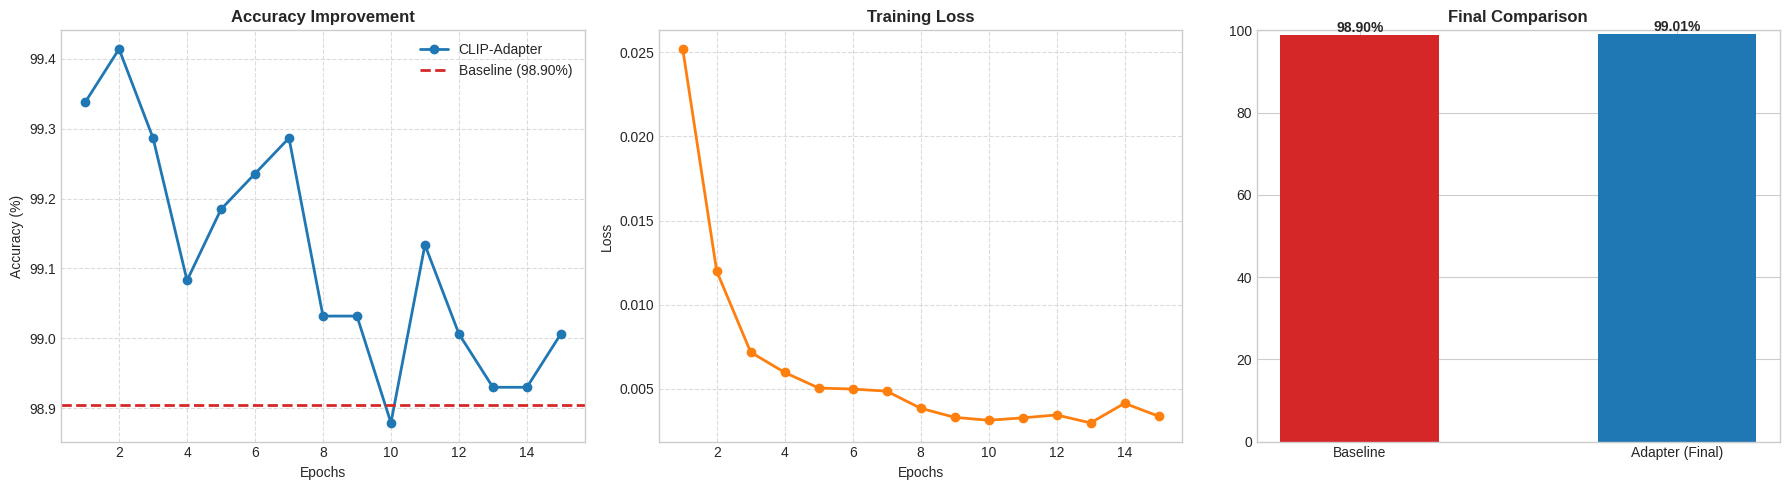

In [17]:
import matplotlib.pyplot as plt
import json
import os

# 1. 自动读取数据
DATA_FILE = "results.json"

if not os.path.exists(DATA_FILE):
    print(f"❌ 错误：找不到 {DATA_FILE}。请先运行修改后的训练脚本。")
    exit()

print(f"正在读取 {DATA_FILE} ...")
with open(DATA_FILE, "r") as f:
    data = json.load(f)

baseline_acc = data["baseline"]
adapter_accs = data["accuracy"]
losses = data["loss"]
epochs = data["epochs"]

# 2. 开始画图 (和之前逻辑一样，但数据是活的)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy Curve
ax1.plot(epochs, adapter_accs, 'o-', color='#1f77b4', linewidth=2, label='CLIP-Adapter')
ax1.axhline(y=baseline_acc, color='#d62728', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc:.2f}%)')
ax1.set_title('Accuracy Improvement', fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Loss Curve
ax2.plot(epochs, losses, 'o-', color='#ff7f0e', linewidth=2)
ax2.set_title('Training Loss', fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)

# Bar Chart
labels = ['Baseline', 'Adapter (Final)']
values = [baseline_acc, adapter_accs[-1]]
colors = ['#d62728', '#1f77b4']
bars = ax3.bar(labels, values, color=colors, width=0.5)
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}%',
             ha='center', va='bottom', fontweight='bold')
ax3.set_title('Final Comparison', fontweight='bold')
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('result_auto.png', dpi=300)
print("✅ 图表已生成：result_auto.png")
plt.show()